In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# Loading Data

In [3]:
df = pd.read_csv('heart disease classification dataset.csv')
df.head()

,Unnamed: 0,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,0,63,male,3,145.0,233.0,1,0,150.0,0,2.3,0,0,1,yes
1,1,37,male,2,130.0,250.0,0,1,187.0,0,3.5,0,0,2,yes
2,2,41,female,1,130.0,204.0,0,0,172.0,0,1.4,2,0,2,yes
3,3,56,male,1,120.0,236.0,0,1,178.0,0,0.8,2,0,2,yes
4,4,57,female,0,NaN,354.0,0,1,163.0,1,0.6,2,0,2,yes


# Cleaning Data

In [9]:
df.drop(['Unnamed: 0'],axis=1,inplace=True)
df.head(1)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,male,3,145.0,233.0,1,0,150.0,0,2.3,0,0,1,yes


In [12]:
df.duplicated(keep=False).sum() # shows total number of duplicate rows

np.int64(2)

In [13]:
df[df.duplicated(keep=False)==True] #shows duplicated rows

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
163,38,male,2,138.0,175.0,0,1,173.0,0,0.0,2,4,2,yes
164,38,male,2,138.0,175.0,0,1,173.0,0,0.0,2,4,2,yes


In [14]:
df.drop_duplicates(keep='first', inplace=True) #delete the duplicate
df.duplicated(keep=False).sum()

np.int64(0)

In [16]:
df.isnull().sum().sort_values(ascending = False)

,0
thalach,5
trestbps,4
chol,1
sex,0
cp,0
age,0
fbs,0
restecg,0
exang,0
oldpeak,0


In [18]:
# taking the mean of the missing values
thelach_mean = df['thalach'].mean()
trestbps_mean = df['trestbps'].mean()
chol_mean = df['chol'].mean()

In [19]:
#filling missing values with mean values
df['thalach'].fillna(value=thelach_mean, inplace=True)
df['trestbps'].fillna(value=trestbps_mean, inplace=True)
df['chol'].fillna(value=chol_mean, inplace=True)

/tmp/ipython-input-1658272994.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['thalach'].fillna(value=thelach_mean, inplace=True)
/tmp/ipython-input-1658272994.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', 

In [20]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 302 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       302 non-null    int64  
 1   sex       302 non-null    object 
 2   cp        302 non-null    int64  
 3   trestbps  302 non-null    float64
 4   chol      302 non-null    float64
 5   fbs       302 non-null    int64  
 6   restecg   302 non-null    int64  
 7   thalach   302 non-null    float64
 8   exang     302 non-null    int64  
 9   oldpeak   302 non-null    float64
 10  slope     302 non-null    int64  
 11  ca        302 non-null    int64  
 12  thal      302 non-null    int64  
 13  target    302 non-null    object 
dtypes: float64(4), int64(8), object(2)
memory usage: 35.4+ KB


In [22]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

# **Splitting**

In [24]:
X = df.iloc[:,:-1]
Y = df.iloc[:,-1]
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)

(241, 13)
(61, 13)


In [25]:
Y_test.iloc[0] # shows the first row

'no'

In [26]:
X_train.head(1)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
132,42,male,1,120.0,295.0,0,1,162.0,0,0.0,2,0,2


# One Hot Encoding

In [28]:
trf = ColumnTransformer(
    transformers=[('One Hot Encoder',OneHotEncoder(),['sex'])],
    remainder = 'passthrough'
)
trf

ColumnTransformer(remainder='passthrough',
                  transformers=[('One Hot Encoder', OneHotEncoder(), ['sex'])])

In [29]:
X_train_trf = trf.fit_transform(X_train)
X_test_trf = trf.transform(X_test)

In [30]:
Y_train.value_counts()
Y_test.value_counts()

,count
target,
yes,32
no,29


# Label Encoder

In [35]:
le = LabelEncoder()
Y_train = le.fit_transform(Y_train)
Y_test = le.transform(Y_test)

In [36]:
print(Y_test[0])

0


# Scaling

In [39]:
sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train_trf)
X_test_scaled = sc.transform(X_test_trf)

In [40]:
X_train_scaled.shape

(241, 14)

# Tensorflow and Keras

In [41]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense

# Model Building

In [42]:
model = Sequential()
model.add(Dense(units=2, activation=keras.activations.leaky_relu, input_dim= 14))
model.add(Dense(units=2, activation=keras.activations.leaky_relu))
model.add(Dense(units=1, activation=keras.activations.sigmoid))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [44]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 2)              │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 39 (156.00 B)

 Trainable params: 39 (156.00 B)

 Non-trainable params: 0 (0.00 B)

# Compile

In [47]:
model.compile(loss=keras.losses.BinaryCrossentropy, optimizer='adam',metrics=['accuracy'])

In [48]:
X_train_scaled.shape

(241, 14)

# Training

In [49]:
History = model.fit(X_train_scaled, Y_train, epochs=50, batch_size=1, validation_data=(X_test_scaled, Y_test))

Epoch 1/50
241/241 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4239 - loss: 0.8198 - val_accuracy: 0.4918 - val_loss: 0.7031
Epoch 2/50
241/241 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5350 - loss: 0.7263 - val_accuracy: 0.6557 - val_loss: 0.6444
Epoch 3/50
241/241 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6988 - loss: 0.6677 - val_accuracy: 0.7213 - val_loss: 0.5888
Epoch 4/50
241/241 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6810 - loss: 0.6146 - val_accuracy: 0.8197 - val_loss: 0.5333
Epoch 5/50
241/241 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7832 - loss: 0.5374 - val_accuracy: 0.8361 - val_loss: 0.4814
Epoch 6/50
241/241 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8315 - loss: 0.4655 - val_accuracy: 0.8361 - val_loss: 0.4377
Epoch 7/50
241/241 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7638 - loss: 0.4675 - val_accuracy: 0.8361 - val_loss: 0.4037
Epoch 8/50
241/241 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8130 - loss: 0.4454 - val_accuracy: 0.

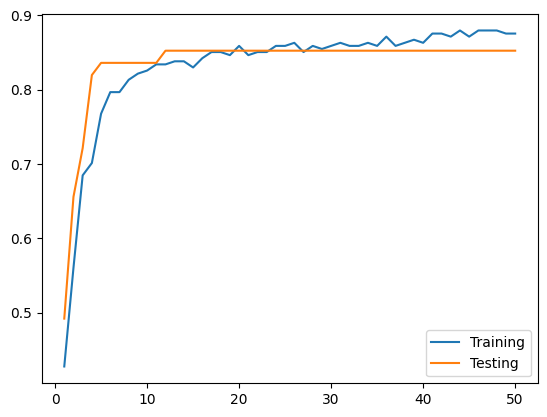

In [52]:
plt.plot(np.arange(1,51),History.history['accuracy'],label='Training')
plt.plot(np.arange(1,51),History.history['val_accuracy'],label='Testing')
plt.legend()
plt.show()

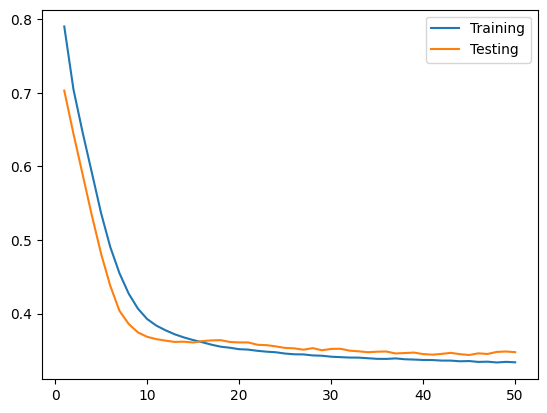

In [53]:
plt.plot(np.arange(1,51),History.history['loss'],label='Training')
plt.plot(np.arange(1,51),History.history['val_loss'],label='Testing')
plt.legend()
plt.show()

In [54]:
model.predict(X_test_scaled)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step 


array([[0.04025875],
       [0.3264309 ],
       [0.9417008 ],
       [0.11384068],
       [0.878968  ],
       [0.96246976],
       [0.7068516 ],
       [0.0404387 ],
       [0.01422172],
       [0.3152895 ],
       [0.8936628 ],
       [0.1703502 ],
       [0.8695947 ],
       [0.04667439],
       [0.9960871 ],
       [0.9822272 ],
       [0.9985246 ],
       [0.00763217],
       [0.01187631],
       [0.03974698],
       [0.6402709 ],
       [0.02154348],
       [0.33007947],
       [0.631754  ],
       [0.9164313 ],
       [0.6098042 ],
       [0.00540583],
       [0.35099283],
       [0.02328876],
       [0.9785727 ],
       [0.06279909],
       [0.04305541],
       [0.30672675],
       [0.13323435],
       [0.8746137 ],
       [0.02908853],
       [0.9317532 ],
       [0.6397884 ],
       [0.8908167 ],
       [0.9635292 ],
       [0.18779178],
       [0.71909827],
       [0.9362724 ],
       [0.943912  ],
       [0.9198101 ],
       [0.07725608],
       [0.9341292 ],
       [0.991

In [55]:
predictions = model.predict(X_test_scaled)
type(predictions)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step 


numpy.ndarray

In [56]:
np.where(predictions>0.5,1,0) # where prediction is greater than 0.5 make it 1 else make it 0

array([[0],
       [0],
       [1],
       [0],
       [1],
       [1],
       [1],
       [0],
       [0],
       [0],
       [1],
       [0],
       [1],
       [0],
       [1],
       [1],
       [1],
       [0],
       [0],
       [0],
       [1],
       [0],
       [0],
       [1],
       [1],
       [1],
       [0],
       [0],
       [0],
       [1],
       [0],
       [0],
       [0],
       [0],
       [1],
       [0],
       [1],
       [1],
       [1],
       [1],
       [0],
       [1],
       [1],
       [1],
       [1],
       [0],
       [1],
       [1],
       [0],
       [0],
       [0],
       [0],
       [1],
       [1],
       [0],
       [0],
       [0],
       [1],
       [0],
       [1],
       [0]])

In [57]:
yp = np.where(predictions>0.5,1,0)

# Evaluation

In [59]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
print('Classification Report:\n', classification_report(Y_test,yp))

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.90      0.85        29
           1       0.90      0.81      0.85        32

    accuracy                           0.85        61
   macro avg       0.85      0.85      0.85        61
weighted avg       0.86      0.85      0.85        61



In [60]:
roc_auc_score(Y_test,yp)

np.float64(0.8545258620689655)

In [61]:
confusion_matrix(Y_test,yp)

array([[26,  3],
       [ 6, 26]])

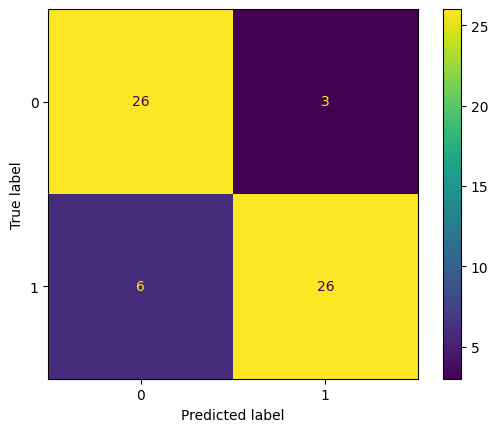

In [62]:
ConfusionMatrixDisplay(confusion_matrix(Y_test,yp)).plot()

In [63]:
Y_test

array([0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0,
       0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0])